In [1]:
import numpy as np
import pandas as pd
import os

os.makedirs("data", exist_ok=True)   # creates a "data" folder if it doesn't exist
rng = np.random.default_rng(42)      # 42 = a "seed" so results are reproducible

TOPICS = ["Algebra", "Geometry", "Trigonometry", "Calculus",
          "Probability & Statistics", "Number Theory"]
N_STUDENTS = 220
QUESTIONS_PER_TOPIC = 8
N_TESTS = 3
MISTAKE_TYPES = ["none", "silly", "conceptual", "calculation"]

print("Setup done. We'll generate data for", N_STUDENTS, "students across", len(TOPICS), "topics.")

Setup done. We'll generate data for 220 students across 6 topics.


In [5]:
rows = []
qid = 0

for student_id in range(1, N_STUDENTS + 1):
    true_skill = {t: rng.beta(2.8, 1.7) for t in TOPICS}
    carelessness = rng.beta(2, 5)

    for test_no in range(1, N_TESTS + 1):
        for topic in TOPICS:
            skill = np.clip(true_skill[topic] + rng.normal(0, 0.05), 0, 1)
            for q in range(QUESTIONS_PER_TOPIC):
                qid += 1
                difficulty = rng.choice(["easy", "medium", "hard"], p=[0.4, 0.4, 0.2])
                diff_penalty = {"easy": 0.02, "medium": 0.10, "hard": 0.22}[difficulty]
                p_correct = np.clip(skill - diff_penalty, 0.03, 0.97)
                is_correct = rng.random() < p_correct

                if is_correct:
                    mistake_type = "none"
                else:
                    weights = np.array([
                        0.0,
                        0.15 + carelessness * 0.6,
                        0.55 + (1 - skill) * 0.3,
                        0.30 + diff_penalty,
                    ])
                    weights = weights / weights.sum()
                    mistake_type = rng.choice(MISTAKE_TYPES, p=weights)

                expected_time = {"easy": 60, "medium": 100, "hard": 150}[difficulty]
                time_taken = max(10, rng.normal(
                    expected_time * (1.3 - 0.3 * skill), expected_time * 0.25))

                rows.append({
                    "question_id": qid,
                    "student_id": student_id,
                    "test_no": test_no,
                    "subject": "Mathematics",
                    "topic": topic,
                    "difficulty": difficulty,
                    "is_correct": int(is_correct),
                    "mistake_type": mistake_type,
                    "time_taken_sec": round(time_taken, 1),
                    "expected_time_sec": expected_time,
                })

df = pd.DataFrame(rows)
df.to_csv("data/answer_sheet_responses.csv", index=False)
print(f"Generated {len(df)} question-level responses")
df.head()

Generated 31680 question-level responses


,question_id,student_id,test_no,subject,topic,difficulty,is_correct,mistake_type,time_taken_sec,expected_time_sec
0,1,1,1,Mathematics,Algebra,easy,0,calculation,75.3,60
1,2,1,1,Mathematics,Algebra,medium,0,conceptual,102.7,100
2,3,1,1,Mathematics,Algebra,medium,1,none,88.1,100
3,4,1,1,Mathematics,Algebra,medium,0,calculation,98.4,100
4,5,1,1,Mathematics,Algebra,easy,0,calculation,55.7,60


In [6]:
# Overall accuracy - should be somewhere reasonable, not 0% or 100%
print("Overall accuracy:", df["is_correct"].mean().round(3))

# How mistakes break down when a question IS wrong
wrong = df[df["is_correct"] == 0]
print("\nMistake type breakdown (among wrong answers):")
print(wrong["mistake_type"].value_counts(normalize=True).round(3))

# Accuracy by topic - some topics should look harder than others
print("\nAccuracy by topic:")
print(df.groupby("topic")["is_correct"].mean().sort_values().round(3))

# Accuracy by difficulty - sanity check: hard should be lower than easy
print("\nAccuracy by difficulty:")
print(df.groupby("difficulty")["is_correct"].mean().round(3))

Overall accuracy: 0.534

Mistake type breakdown (among wrong answers):
mistake_type
conceptual     0.481
calculation    0.287
silly          0.232
Name: proportion, dtype: float64

Accuracy by topic:
topic
Algebra                     0.515
Trigonometry                0.529
Probability & Statistics    0.531
Calculus                    0.538
Geometry                    0.540
Number Theory               0.552
Name: is_correct, dtype: float64

Accuracy by difficulty:
difficulty
easy      0.606
hard      0.404
medium    0.526
Name: is_correct, dtype: float64


In [7]:
# Group by student + topic, and calculate aggregate features
def mistake_rate(group, mtype):
    wrong = group[group["is_correct"] == 0]
    if len(wrong) == 0:
        return 0.0
    return (wrong["mistake_type"] == mtype).mean()

features = []
for (student_id, topic), group in df.groupby(["student_id", "topic"]):
    features.append({
        "student_id": student_id,
        "topic": topic,
        "accuracy": group["is_correct"].mean(),
        "silly_rate": mistake_rate(group, "silly"),
        "conceptual_rate": mistake_rate(group, "conceptual"),
        "calculation_rate": mistake_rate(group, "calculation"),
        "avg_time_ratio": (group["time_taken_sec"] / group["expected_time_sec"]).mean(),
        "n_questions": len(group),
    })

feat_df = pd.DataFrame(features)
feat_df["is_weak"] = (feat_df["accuracy"] < 0.5).astype(int)

feat_df.to_csv("data/student_topic_features.csv", index=False)
print(f"Built {len(feat_df)} student-topic rows")
print("\nWeak topic rate:", feat_df["is_weak"].mean().round(3))
feat_df.head(10)

Built 1320 student-topic rows

Weak topic rate: 0.403


,student_id,topic,accuracy,silly_rate,conceptual_rate,calculation_rate,avg_time_ratio,n_questions,is_weak
0,1,Algebra,0.541667,0.090909,0.454545,0.454545,1.120458,24,0
1,1,Calculus,0.375000,0.200000,0.466667,0.333333,1.187861,24,1
2,1,Geometry,0.791667,0.000000,0.400000,0.600000,1.004222,24,0
3,1,Number Theory,0.166667,0.300000,0.400000,0.300000,1.200639,24,1
4,1,Probability & Statistics,0.875000,0.000000,0.666667,0.333333,1.065569,24,0
5,1,Trigonometry,0.791667,0.200000,0.200000,0.600000,0.930569,24,0
6,2,Algebra,0.500000,0.083333,0.500000,0.416667,1.071333,24,0
7,2,Calculus,0.250000,0.166667,0.555556,0.277778,1.182583,24,1
8,2,Geometry,0.208333,0.263158,0.578947,0.157895,1.286778,24,1
9,2,Number Theory,0.125000,0.285714,0.333333,0.380952,1.234889,24,1


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier

# Features the model is allowed to see (NOT accuracy - that would be cheating)
feature_cols = ["silly_rate", "conceptual_rate", "calculation_rate",
                 "avg_time_ratio"]

X = feat_df[feature_cols]
y = feat_df["is_weak"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")

model = ExtraTreesClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")

Training rows: 1056, Test rows: 264
Model trained.


In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, confusion_matrix, classification_report)

y_pred = model.predict(X_test)

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1-score: ", round(f1_score(y_test, y_pred), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("(rows = actual, columns = predicted | order: [Not-Weak, Weak])")

print("\nFull report:")
print(classification_report(y_test, y_pred, target_names=["Not Weak", "Weak"]))

print("\nWhich signals mattered most:")
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.round(3))

Accuracy:  0.867
Precision: 0.859
Recall:    0.802
F1-score:  0.829

Confusion Matrix:
[[144  14]
 [ 21  85]]
(rows = actual, columns = predicted | order: [Not-Weak, Weak])

Full report:
              precision    recall  f1-score   support

    Not Weak       0.87      0.91      0.89       158
        Weak       0.86      0.80      0.83       106

    accuracy                           0.87       264
   macro avg       0.87      0.86      0.86       264
weighted avg       0.87      0.87      0.87       264


Which signals mattered most:
avg_time_ratio      0.436
calculation_rate    0.209
conceptual_rate     0.182
silly_rate          0.172
dtype: float64


Matplotlib is building the font cache; this may take a moment.


Model saved to models/weak_topic_model.pkl


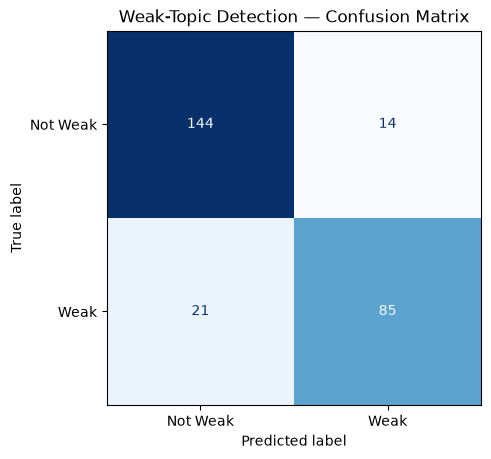

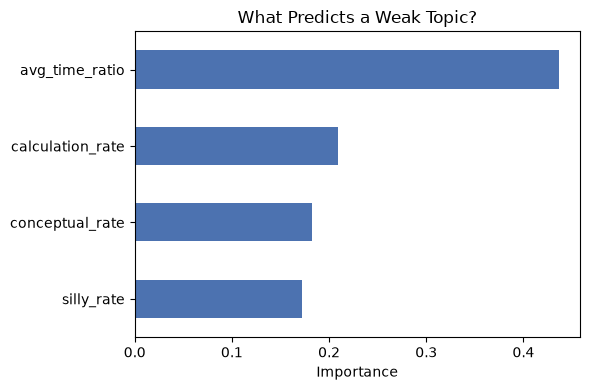


Saved: outputs/confusion_matrix.png and outputs/feature_importance.png


In [12]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Save the trained model to disk
joblib.dump(model, "models/weak_topic_model.pkl")
print("Model saved to models/weak_topic_model.pkl")

# Build a clean confusion matrix image
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Not Weak", "Weak"],
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Weak-Topic Detection — Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

# Build a feature importance chart too - useful for your slides
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("What Predicts a Weak Topic?")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150)
plt.show()

print("\nSaved: outputs/confusion_matrix.png and outputs/feature_importance.png")

In [13]:
def diagnose_student(answer_rows, model, feature_cols):
    """
    answer_rows: list of dicts, each like:
        {"topic": "Algebra", "is_correct": 0, "mistake_type": "conceptual",
         "time_taken_sec": 140, "expected_time_sec": 100}
    Returns a diagnosis: weak topics, reasons, and a study plan.
    """
    student_df = pd.DataFrame(answer_rows)

    topic_features = []
    for topic, group in student_df.groupby("topic"):
        topic_features.append({
            "topic": topic,
            "accuracy": group["is_correct"].mean(),
            "silly_rate": mistake_rate(group, "silly"),
            "conceptual_rate": mistake_rate(group, "conceptual"),
            "calculation_rate": mistake_rate(group, "calculation"),
            "avg_time_ratio": (group["time_taken_sec"] / group["expected_time_sec"]).mean(),
        })
    tf = pd.DataFrame(topic_features)

    X_new = tf[feature_cols]
    tf["predicted_weak"] = model.predict(X_new)
    tf["weak_probability"] = model.predict_proba(X_new)[:, 1]

    weak = tf[tf["predicted_weak"] == 1].sort_values("weak_probability", ascending=False)

    print("=" * 55)
    print("STUDENT DIAGNOSIS REPORT")
    print("=" * 55)

    if len(weak) == 0:
        print("No weak topics detected. Student is performing consistently.")
        return tf

    print(f"\n{len(weak)} weak topic(s) identified:\n")
    for _, row in weak.iterrows():
        # figure out the dominant mistake reason
        reasons = {"silly": row["silly_rate"], "conceptual": row["conceptual_rate"],
                   "calculation": row["calculation_rate"]}
        main_reason = max(reasons, key=reasons.get)

        print(f"  • {row['topic']}  (confidence: {row['weak_probability']:.0%})")
        print(f"    Mainly {main_reason} mistakes | "
              f"time spent: {row['avg_time_ratio']:.1f}x expected")

        if main_reason == "conceptual":
            print(f"    → Study plan: Revisit core {row['topic']} concepts before practicing more questions.")
        elif main_reason == "silly":
            print(f"    → Study plan: Practice with a focus on double-checking work, not new concepts.")
        else:
            print(f"    → Study plan: Drill calculation speed/accuracy with timed {row['topic']} problem sets.")
        print()

    return tf

print("Agent function ready.")

Agent function ready.


In [14]:
# Simulate one new student's answers across 2 topics (in reality, this would
# come from your OCR/answer-sheet-parsing pipeline)
demo_answers = []

# Weak in Algebra - lots of conceptual mistakes, slow
for i in range(12):
    is_correct = 1 if i % 3 == 0 else 0  # ~33% accuracy
    demo_answers.append({
        "topic": "Algebra",
        "is_correct": is_correct,
        "mistake_type": "none" if is_correct else "conceptual",
        "time_taken_sec": 160,
        "expected_time_sec": 100,
    })

# Strong in Geometry - occasional silly slip, fast
for i in range(12):
    is_correct = 1 if i % 5 != 0 else 0  # ~80% accuracy
    demo_answers.append({
        "topic": "Geometry",
        "is_correct": is_correct,
        "mistake_type": "none" if is_correct else "silly",
        "time_taken_sec": 85,
        "expected_time_sec": 100,
    })

result = diagnose_student(demo_answers, model, feature_cols)

STUDENT DIAGNOSIS REPORT

1 weak topic(s) identified:

  • Algebra  (confidence: 51%)
    Mainly conceptual mistakes | time spent: 1.6x expected
    → Study plan: Revisit core Algebra concepts before practicing more questions.



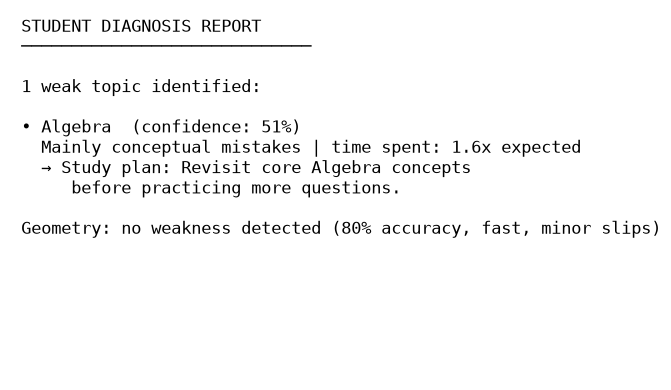

Saved: outputs/sample_diagnosis.png


In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.axis("off")

report_text = (
    "STUDENT DIAGNOSIS REPORT\n"
    "─────────────────────────────\n\n"
    "1 weak topic identified:\n\n"
    "• Algebra  (confidence: 51%)\n"
    "  Mainly conceptual mistakes | time spent: 1.6x expected\n"
    "  → Study plan: Revisit core Algebra concepts\n"
    "     before practicing more questions.\n\n"
    "Geometry: no weakness detected (80% accuracy, fast, minor slips)"
)

ax.text(0.02, 0.98, report_text, va="top", ha="left", fontsize=12,
        family="monospace", transform=ax.transAxes)
plt.tight_layout()
plt.savefig("outputs/sample_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/sample_diagnosis.png")

In [1]:
import json

with open("question_bank.json") as f:
    qbank = json.load(f)["questions"]

with open("student_answers.json") as f:
    students = json.load(f)["students"]

# Turn question bank into a lookup by ID for easy access
qbank_lookup = {q["id"]: q for q in qbank}

def check_answer(answer_text, question):
    """Returns 'full', 'partial', or 'missing' for one answer."""
    text = answer_text.lower()
    required = [str(e).lower() for e in question["required_elements"]]
    partial = [str(e).lower() for e in question["partial_credit_elements"]]

    required_present = all(elem in text for elem in required)
    partial_present = all(elem in text for elem in partial)

    if required_present:
        return "full"
    elif partial_present:
        return "partial"
    else:
        return "missing"

# Test it on all students
results = []
for student in students:
    for q_id, answer_text in student["answers"].items():
        question = qbank_lookup[q_id]
        match_status = check_answer(answer_text, question)
        results.append({
            "student_id": student["student_id"],
            "question_id": q_id,
            "concept": question["concept"],
            "match_status": match_status
        })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

student_id question_id                       concept match_status
         A          Q1      Factorial simplification      partial
         A          Q2      Factorial simplification      missing
         A          Q3            Angle-sum property         full
         A          Q4            Angle-sum property         full
         A          Q5    Trigonometric table values         full
         A          Q6    Trigonometric table values         full
         A          Q7 Quadratic formula application      missing
         A          Q8 Quadratic formula application      missing
         B          Q1      Factorial simplification         full
         B          Q2      Factorial simplification         full
         B          Q3            Angle-sum property         full
         B          Q4            Angle-sum property         full
         B          Q5    Trigonometric table values         full
         B          Q6    Trigonometric table values         full
         B

In [2]:
def diagnose_concepts(student_results):
    """Takes the per-question results for ONE student, returns concept-level diagnosis."""
    df = pd.DataFrame(student_results)

    concept_summary = []
    for concept, group in df.groupby("concept"):
        total = len(group)
        full = (group["match_status"] == "full").sum()
        partial = (group["match_status"] == "partial").sum()
        missing = (group["match_status"] == "missing").sum()

        # Weakness score: full=1 point, partial=0.5, missing=0 point
        score = (full * 1 + partial * 0.5) / total

        if score >= 0.8:
            status = "Strong"
        elif score >= 0.5:
            status = "Partial gap"
        else:
            status = "Weak"

        # Diagnose WHY
        if missing > 0 and partial == 0:
            reason = "Missing key steps/values entirely — likely a conceptual gap"
        elif partial > 0 and missing == 0:
            reason = "Method correct but final answer wrong — likely a calculation slip"
        elif missing > 0 and partial > 0:
            reason = "Mixed: some conceptual gaps, some calculation errors"
        else:
            reason = "Consistently correct"

        concept_summary.append({
            "concept": concept,
            "status": status,
            "score": round(score, 2),
            "reason": reason
        })

    return pd.DataFrame(concept_summary).sort_values("score")

# Run for each student
for student_id in ["A", "B", "C"]:
    student_data = results_df[results_df["student_id"] == student_id].to_dict("records")
    print(f"\n{'='*50}\nSTUDENT {student_id} — CONCEPT DIAGNOSIS\n{'='*50}")
    print(diagnose_concepts(student_data).to_string(index=False))


STUDENT A — CONCEPT DIAGNOSIS
                      concept status  score                                                      reason
Quadratic formula application   Weak   0.00 Missing key steps/values entirely — likely a conceptual gap
     Factorial simplification   Weak   0.25        Mixed: some conceptual gaps, some calculation errors
           Angle-sum property Strong   1.00                                        Consistently correct
   Trigonometric table values Strong   1.00                                        Consistently correct

STUDENT B — CONCEPT DIAGNOSIS
                      concept status  score               reason
           Angle-sum property Strong    1.0 Consistently correct
     Factorial simplification Strong    1.0 Consistently correct
Quadratic formula application Strong    1.0 Consistently correct
   Trigonometric table values Strong    1.0 Consistently correct

STUDENT C — CONCEPT DIAGNOSIS
                      concept      status  score              

In [3]:
def full_diagnosis_pipeline(answers_dict, qbank_lookup):
    """
    answers_dict: {"Q1": "answer text", "Q2": "answer text", ...}
    Returns: concept-level diagnosis DataFrame
    """
    results = []
    for q_id, answer_text in answers_dict.items():
        question = qbank_lookup[q_id]
        match_status = check_answer(answer_text, question)
        results.append({
            "question_id": q_id,
            "concept": question["concept"],
            "match_status": match_status
        })
    return diagnose_concepts(results)

# Quick test - should match Student A's report above
test_result = full_diagnosis_pipeline(students[0]["answers"], qbank_lookup)
print(test_result.to_string(index=False))

                      concept status  score                                                      reason
Quadratic formula application   Weak   0.00 Missing key steps/values entirely — likely a conceptual gap
     Factorial simplification   Weak   0.25        Mixed: some conceptual gaps, some calculation errors
           Angle-sum property Strong   1.00                                        Consistently correct
   Trigonometric table values Strong   1.00                                        Consistently correct
